In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/processed/train_raw.csv',
                    index_col='date', parse_dates=True)
test  = pd.read_csv('../data/processed/test_raw.csv',
                    index_col='date', parse_dates=True)

# Prophet requires exactly these column names
train_prophet = train.reset_index().rename(
    columns={'date': 'ds', 'total_sales': 'y'})
test_prophet  = test.reset_index().rename(
    columns={'date': 'ds', 'total_sales': 'y'})

print('Train shape:', train_prophet.shape)
print('Test shape: ', test_prophet.shape)
print('\nProphet format sample:')
print(train_prophet.tail())

Train shape: (1669, 2)
Test shape:  (15, 2)

Prophet format sample:
             ds            y
1664 2017-07-27  10078.64200
1665 2017-07-28  11361.68900
1666 2017-07-29  10165.19200
1667 2017-07-30   4950.21599
1668 2017-07-31  11626.72500


In [2]:
# Build and train prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)

print('Training Prophet...')
model.fit(train_prophet)
print('Training complete!')

20:31:38 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet...


20:31:39 - cmdstanpy - INFO - Chain [1] done processing


Training complete!


In [3]:
# Generate forecast

# Create future dataframe for forecast period
future = model.make_future_dataframe(
    periods=len(test),
    freq='D'
)

# Generate forecast
forecast = model.predict(future)

# Extract only test period predictions
forecast_test = forecast[
    forecast['ds'] >= test_prophet['ds'].min()
].reset_index(drop=True)

print(f'Forecast period: {forecast_test["ds"].min()} → {forecast_test["ds"].max()}')
print(f'\nForecast columns available:')
print(forecast.columns.tolist())
print(f'\nForecast sample:')
print(forecast_test[['ds', 'yhat',
                      'yhat_lower',
                      'yhat_upper']].head(10))

Forecast period: 2017-08-01 00:00:00 → 2017-08-15 00:00:00

Forecast columns available:
['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']

Forecast sample:
          ds          yhat    yhat_lower    yhat_upper
0 2017-08-01  10705.325360   8275.415523  12888.975615
1 2017-08-02  12793.902583  10422.113455  15054.884410
2 2017-08-03  10151.038778   7949.707573  12282.974308
3 2017-08-04  11348.595266   8931.616364  13569.714979
4 2017-08-05  10620.623175   8460.926922  12847.209448
5 2017-08-06   5584.432476   3206.641458   7764.109332
6 2017-08-07  10380.396653   7992.109024  12455.265082
7 2017-08-08  10136.017173   7769.835776  12305.544583
8 2017-08-09  12273.388596  10004.468752  14647.962693
9 2017-08-10   9688.159739  

In [4]:
# Evaluate Prophet

actual    = test_prophet['y'].values
predicted = forecast_test['yhat'].values

mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs(
    (actual - predicted) / actual)) * 100

print('=== Prophet Performance ===')
print(f'MAE:  {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'MAPE: {mape:.2f}%')
print(f'\nComparison:')
print(f'ARIMA  MAPE: 24.77%')
print(f'Prophet MAPE: {mape:.2f}%')
improvement = 24.77 - mape
print(f'Improvement: {improvement:+.2f}%')

=== Prophet Performance ===
MAE:  1,325.19
RMSE: 1,858.12
MAPE: 18.87%

Comparison:
ARIMA  MAPE: 24.77%
Prophet MAPE: 18.87%
Improvement: +5.90%


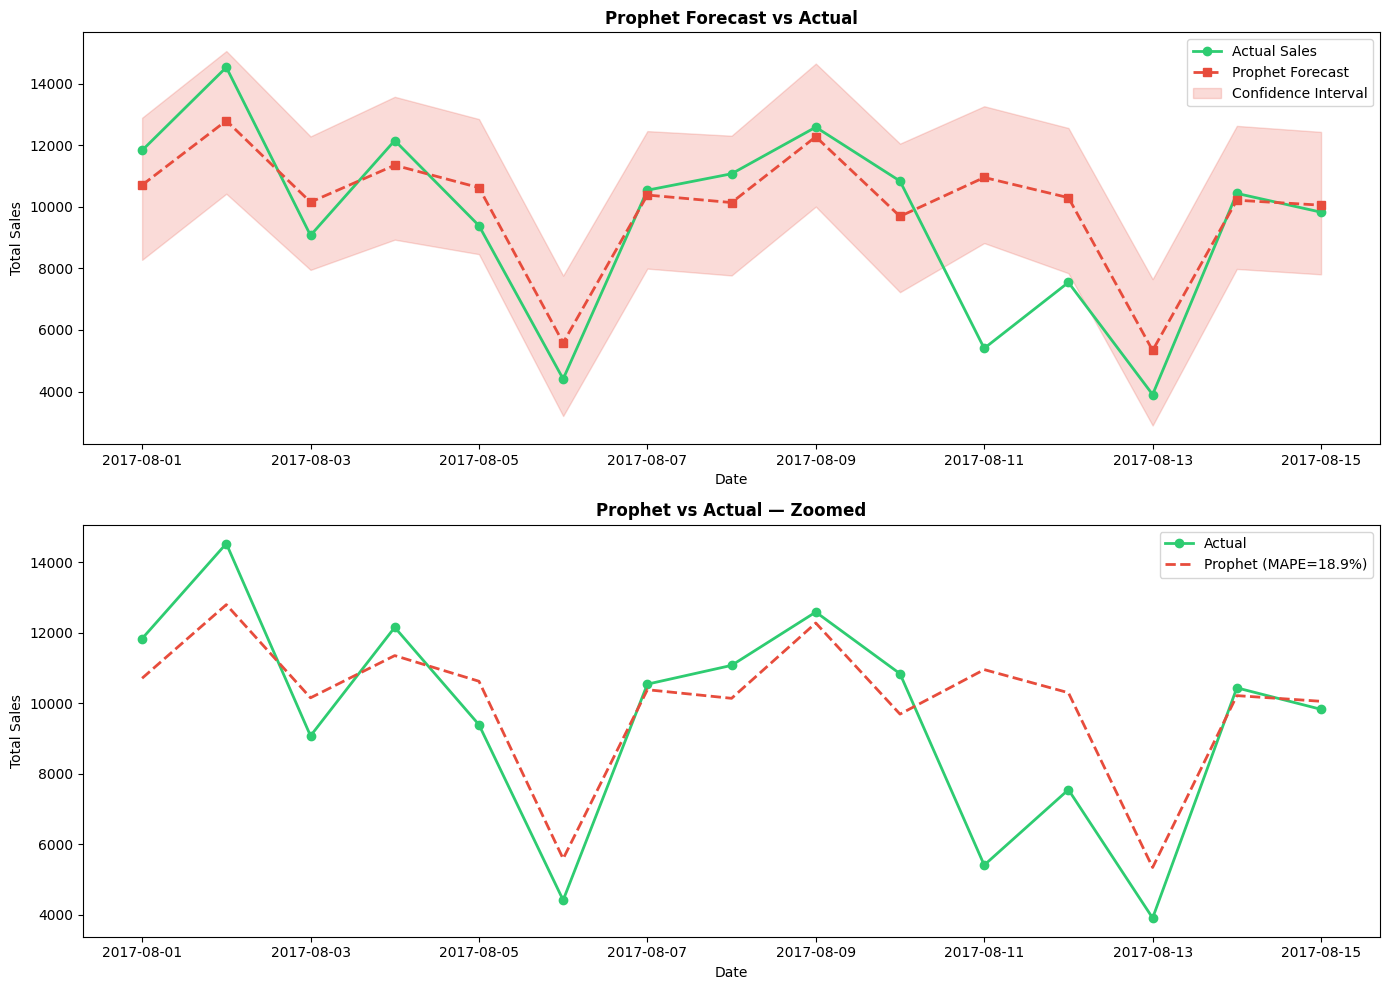

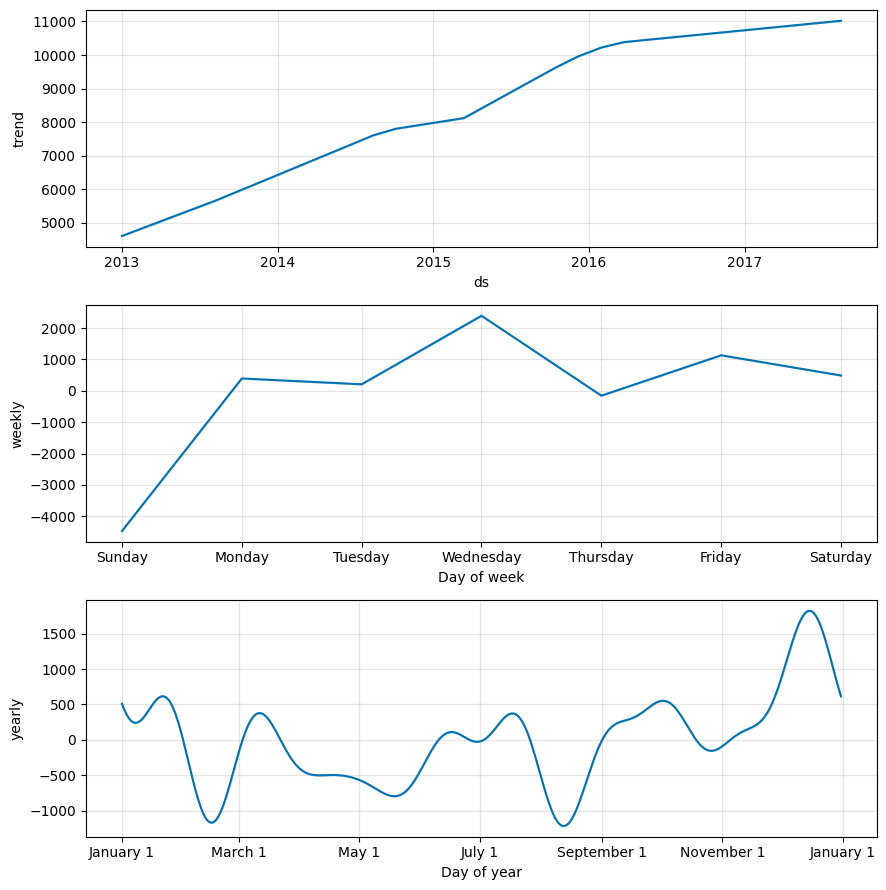

In [5]:
# Plot Prophet Components

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Forecast vs Actual
axes[0].plot(test_prophet['ds'],
             test_prophet['y'],
             color='#2ecc71', linewidth=2,
             marker='o', label='Actual Sales')
axes[0].plot(forecast_test['ds'],
             forecast_test['yhat'],
             color='#e74c3c', linewidth=2,
             marker='s', linestyle='--',
             label='Prophet Forecast')
axes[0].fill_between(
    forecast_test['ds'],
    forecast_test['yhat_lower'],
    forecast_test['yhat_upper'],
    alpha=0.2, color='#e74c3c',
    label='Confidence Interval'
)
axes[0].set_title('Prophet Forecast vs Actual',
                  fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales')

# Plot 2 — ARIMA vs Prophet comparison
axes[1].plot(test_prophet['ds'],
             test_prophet['y'],
             color='#2ecc71', linewidth=2,
             marker='o', label='Actual')
axes[1].plot(forecast_test['ds'],
             forecast_test['yhat'],
             color='#e74c3c', linewidth=2,
             linestyle='--', label=f'Prophet (MAPE={mape:.1f}%)')

arima_forecast = pd.read_csv(
    '../data/processed/train_raw.csv',
    index_col='date', parse_dates=True)

axes[1].set_title('Prophet vs Actual — Zoomed',
                  fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Sales')

plt.tight_layout()
plt.savefig('../reports/figures/07_prophet_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Prophet component plots
fig2 = model.plot_components(forecast)
fig2.savefig('../reports/figures/08_prophet_components.png',
             dpi=150, bbox_inches='tight')
plt.show()